# Convolutional Neural Network Example

Build a convolutional neural network with TensorFlow v2.

This example is using a low-level approach to better understand all mechanics behind building convolutional neural networks and the training process.

- Author: Aymeric Damien
- Project: https://github.com/aymericdamien/TensorFlow-Examples/

## CNN Overview

![CNN](http://personal.ie.cuhk.edu.hk/~ccloy/project_target_code/images/fig3.png)

## MNIST Dataset Overview

This example is using MNIST handwritten digits. The dataset contains 60,000 examples for training and 10,000 examples for testing. The digits have been size-normalized and centered in a fixed-size image (28x28 pixels) with values from 0 to 255. 

In this example, each image will be converted to float32 and normalized to [0, 1].

![MNIST Dataset](http://neuralnetworksanddeeplearning.com/images/mnist_100_digits.png)

More info: http://yann.lecun.com/exdb/mnist/

In [3]:
from __future__ import absolute_import, division, print_function

import tensorflow as tf
from tensorflow.keras import Model, layers
import numpy as np

In [4]:
# MNIST dataset parameters.
num_classes = 10 # total classes (0-9 digits).

# Training parameters.
learning_rate = 0.001
training_steps = 200
batch_size = 128
display_step = 10

# Network parameters.
conv1_filters = 32 # number of filters for 1st conv layer.
conv2_filters = 64 # number of filters for 2nd conv layer.
fc1_units = 1024 # number of neurons for 1st fully-connected layer.

In [5]:
# Prepare MNIST data.
from tensorflow.keras.datasets import mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()
# Convert to float32.
x_train, x_test = np.array(x_train, np.float32), np.array(x_test, np.float32)
# Normalize images value from [0, 255] to [0, 1].
x_train, x_test = x_train / 255., x_test / 255.

In [6]:
# Use tf.data API to shuffle and batch data.
train_data = tf.data.Dataset.from_tensor_slices((x_train, y_train))
train_data = train_data.repeat().shuffle(5000).batch(batch_size).prefetch(1)

In [7]:
# Create TF Model.
class ConvNet(Model):
    # Set layers.
    def __init__(self):
        super(ConvNet, self).__init__()
        # Convolution Layer with 32 filters and a kernel size of 5.
        self.conv1 = layers.Conv2D(32, kernel_size=5, activation=tf.nn.relu)
        # Max Pooling (down-sampling) with kernel size of 2 and strides of 2. 
        self.maxpool1 = layers.MaxPool2D(2, strides=2)

        # Convolution Layer with 64 filters and a kernel size of 3.
        self.conv2 = layers.Conv2D(64, kernel_size=3, activation=tf.nn.relu)
        # Max Pooling (down-sampling) with kernel size of 2 and strides of 2. 
        self.maxpool2 = layers.MaxPool2D(2, strides=2)

        # Flatten the data to a 1-D vector for the fully connected layer.
        self.flatten = layers.Flatten()

        # Fully connected layer.
        self.fc1 = layers.Dense(1024)
        # Apply Dropout (if is_training is False, dropout is not applied).
        self.dropout = layers.Dropout(rate=0.5)

        # Output layer, class prediction.
        self.out = layers.Dense(num_classes)

    # Set forward pass.
    def call(self, x, is_training=False):
        x = tf.reshape(x, [-1, 28, 28, 1])
        x = self.conv1(x)
        x = self.maxpool1(x)
        x = self.conv2(x)
        x = self.maxpool2(x)
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.dropout(x, training=is_training)
        x = self.out(x)
        if not is_training:
            # tf cross entropy expect logits without softmax, so only
            # apply softmax when not training.
            x = tf.nn.softmax(x)
        return x

# Build neural network model.
conv_net = ConvNet()

In [8]:
# Cross-Entropy Loss.
# Note that this will apply 'softmax' to the logits.
def cross_entropy_loss(x, y):
    # Convert labels to int 64 for tf cross-entropy function.
    y = tf.cast(y, tf.int64)
    # Apply softmax to logits and compute cross-entropy.
    loss = tf.nn.sparse_softmax_cross_entropy_with_logits(labels=y, logits=x)
    # Average loss across the batch.
    return tf.reduce_mean(loss)

# Accuracy metric.
def accuracy(y_pred, y_true):
    # Predicted class is the index of highest score in prediction vector (i.e. argmax).
    correct_prediction = tf.equal(tf.argmax(y_pred, 1), tf.cast(y_true, tf.int64))
    return tf.reduce_mean(tf.cast(correct_prediction, tf.float32), axis=-1)

# Stochastic gradient descent optimizer.
optimizer = tf.optimizers.Adam(learning_rate)

In [9]:
# Optimization process. 
def run_optimization(x, y):
    # Wrap computation inside a GradientTape for automatic differentiation.
    with tf.GradientTape() as g:
        # Forward pass.
        pred = conv_net(x, is_training=True)
        # Compute loss.
        loss = cross_entropy_loss(pred, y)
        
    # Variables to update, i.e. trainable variables.
    trainable_variables = conv_net.trainable_variables

    # Compute gradients.
    gradients = g.gradient(loss, trainable_variables)
    
    # Update W and b following gradients.
    optimizer.apply_gradients(zip(gradients, trainable_variables))

In [10]:
# Run training for the given number of steps.
for step, (batch_x, batch_y) in enumerate(train_data.take(training_steps), 1):
    # Run the optimization to update W and b values.
    run_optimization(batch_x, batch_y)
    
    if step % display_step == 0:
        pred = conv_net(batch_x)
        loss = cross_entropy_loss(pred, batch_y)
        acc = accuracy(pred, batch_y)
        print("step: %i, loss: %f, accuracy: %f" % (step, loss, acc))

step: 10, loss: 1.766798, accuracy: 0.875000
step: 20, loss: 1.594200, accuracy: 0.890625
step: 30, loss: 1.588348, accuracy: 0.929688
step: 40, loss: 1.570319, accuracy: 0.945312
step: 50, loss: 1.551559, accuracy: 0.953125
step: 60, loss: 1.560505, accuracy: 0.921875
step: 70, loss: 1.533705, accuracy: 0.945312
step: 80, loss: 1.535795, accuracy: 0.968750
step: 90, loss: 1.529034, accuracy: 0.968750
step: 100, loss: 1.509244, accuracy: 0.968750
step: 110, loss: 1.529533, accuracy: 0.945312
step: 120, loss: 1.497324, accuracy: 0.984375
step: 130, loss: 1.519614, accuracy: 0.953125
step: 140, loss: 1.505471, accuracy: 0.984375
step: 150, loss: 1.500967, accuracy: 0.976562
step: 160, loss: 1.496413, accuracy: 0.984375
step: 170, loss: 1.523703, accuracy: 0.945312
step: 180, loss: 1.486354, accuracy: 0.992188
step: 190, loss: 1.491980, accuracy: 0.984375
step: 200, loss: 1.490998, accuracy: 0.984375


In [11]:
# Test model on validation set.
pred = conv_net(x_test)
print("Test Accuracy: %f" % accuracy(pred, y_test))

Test Accuracy: 0.980600


In [12]:
# Visualize predictions.
import matplotlib.pyplot as plt

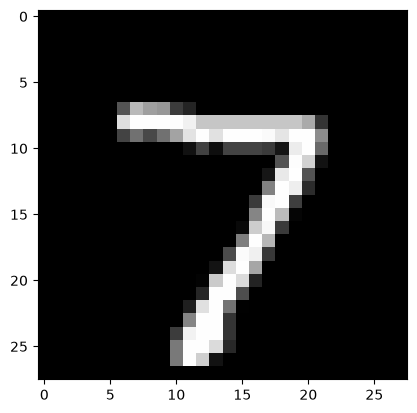

Model prediction: 7


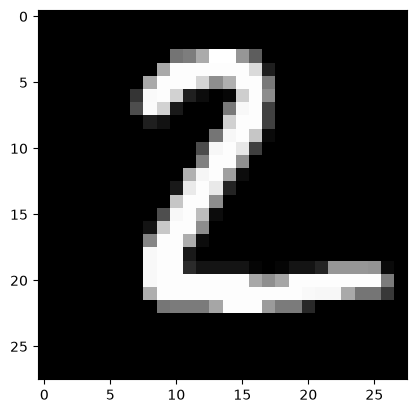

Model prediction: 2


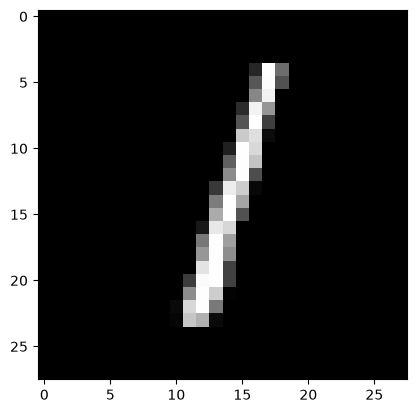

Model prediction: 1


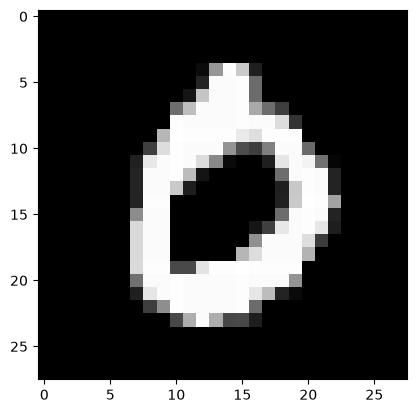

Model prediction: 0


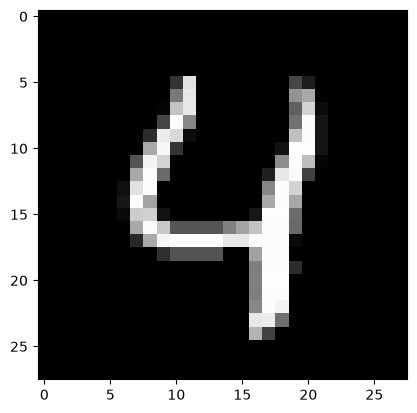

Model prediction: 4


In [13]:
# Predict 5 images from validation set.
n_images = 5
test_images = x_test[:n_images]
predictions = conv_net(test_images)

# Display image and model prediction.
for i in range(n_images):
    plt.imshow(np.reshape(test_images[i], [28, 28]), cmap='gray')
    plt.show()
    print("Model prediction: %i" % np.argmax(predictions.numpy()[i]))

## Input your own image here 

(via Paths "resources/<image_name>.jpg")

The image will be resized to 28x28 pixels and converted to grayscale before being fed to the model.

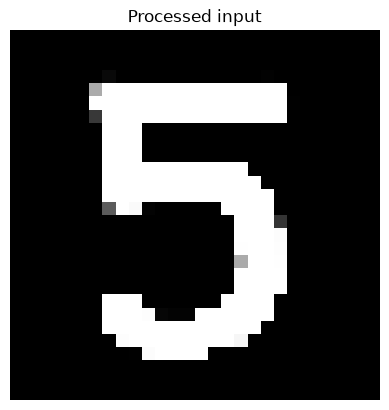

Model prediction: 5


In [15]:
# Predict a custom image file with the trained model.
from pathlib import Path
from tensorflow.keras.utils import load_img, img_to_array

# Try common paths relative to notebook working directory.
paths_to_try = [
    #change image file here
    "resources/hi.jpg"
]
custom_image_path = next((p for p in paths_to_try if Path(p).exists()), paths_to_try[0])

img = load_img(custom_image_path, color_mode="grayscale", target_size=(28, 28))
img = img_to_array(img).astype("float32") / 255.0

# MNIST digits are white on black. Invert when the image background is bright.
if np.mean(img) > 0.5:
    img = 1.0 - img

img = np.expand_dims(img, axis=0)
pred = conv_net(img)
pred_class = int(np.argmax(pred.numpy()[0]))

plt.imshow(np.reshape(img[0], [28, 28]), cmap="gray")
plt.title("Processed input")
plt.axis("off")
plt.show()

print("Model prediction:", pred_class)

For Custom Images, you can use the following code to load and preprocess the image:

Selected file: D:/BBU/Y4_S1/Foundation of ML and AI/TensorFlow/resources/my_digit.jpg


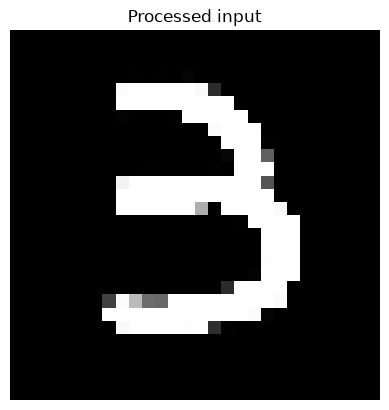

Model prediction: 3


In [20]:
# Predict a custom image file with the trained model.
import numpy as np
from pathlib import Path
from tensorflow.keras.utils import load_img, img_to_array
import tkinter as tk
from tkinter import filedialog

# Open a file picker dialog so you can choose the image each time you run this cell.
root = tk.Tk()
root.withdraw()          # hide the empty tkinter window
root.attributes("-topmost", True)  # bring the dialog to the front
custom_image_path = filedialog.askopenfilename(
    title="Select an image to predict",
    filetypes=[("Image files", "*.jpg *.jpeg *.png *.bmp *.gif")]
)
root.destroy()

if not custom_image_path:
    raise ValueError("No file selected.")

print("Selected file:", custom_image_path)

img = load_img(custom_image_path, color_mode="grayscale", target_size=(28, 28))
img = img_to_array(img).astype("float32") / 255.0

# MNIST digits are white on black. Invert when the image background is bright.
if np.mean(img) > 0.5:
    img = 1.0 - img

img = np.expand_dims(img, axis=0)
pred = conv_net(img)
pred_class = int(np.argmax(pred.numpy()[0]))

plt.imshow(np.reshape(img[0], [28, 28]), cmap="gray")
plt.title("Processed input")
plt.axis("off")
plt.show()
print("Model prediction:", pred_class)